In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway

np.random.seed(42)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 5.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# ── Load your dataset ────────────────────────────────────────────────────────
# Upload the CSV to Colab first (use Files panel on the left), then run this:
df = pd.read_csv('online_learning_course_consumption_dataset.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

Shape: (500, 10)
Columns: ['User_ID', 'Experience_Level', 'Course_Type', 'Platform', 'Hours_Spent_Per_Week', 'Course_Duration_Weeks', 'Completion_Status', 'Completion_Percentage', 'Dropout_Reason', 'Satisfaction_Score']


,User_ID,Experience_Level,Course_Type,Platform,Hours_Spent_Per_Week,Course_Duration_Weeks,Completion_Status,Completion_Percentage,Dropout_Reason,Satisfaction_Score
0,U0001,Fresher,Tech,Skillshare,16,8,Completed,67,No Dropout,2
1,U0002,Fresher,Non-Tech,edX,17,22,Dropped,38,Time Constraint,3
2,U0003,Fresher,Non-Tech,Coursera,19,21,In Progress,43,No Dropout,1
3,U0004,Student,Non-Tech,Udemy,14,2,Dropped,14,Time Constraint,1
4,U0005,Student,Non-Tech,Skillshare,8,10,Dropped,8,Too Difficult,4
5,U0006,Working Professional,Tech,Coursera,11,11,In Progress,53,No Dropout,4
6,U0007,Working Professional,Tech,YouTube,12,19,Dropped,34,Too Difficult,4
7,U0008,Fresher,Tech,Skillshare,1,17,Dropped,37,Too Difficult,1
8,U0009,Fresher,Non-Tech,Skillshare,12,14,Completed,51,No Dropout,1
9,U0010,Working Professional,Non-Tech,edX,5,15,Completed,98,No Dropout,1


In [3]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nValue counts – Experience_Level:')
print(df['Experience_Level'].value_counts())
print('\nValue counts – Completion_Status:')
print(df['Completion_Status'].value_counts())

User_ID                  object
Experience_Level         object
Course_Type              object
Platform                 object
Hours_Spent_Per_Week      int64
Course_Duration_Weeks     int64
Completion_Status        object
Completion_Percentage     int64
Dropout_Reason           object
Satisfaction_Score        int64
dtype: object

Missing values:
User_ID                  0
Experience_Level         0
Course_Type              0
Platform                 0
Hours_Spent_Per_Week     0
Course_Duration_Weeks    0
Completion_Status        0
Completion_Percentage    0
Dropout_Reason           0
Satisfaction_Score       0
dtype: int64

Value counts – Experience_Level:
Experience_Level
Working Professional    173
Fresher                 171
Student                 156
Name: count, dtype: int64

Value counts – Completion_Status:
Completion_Status
Dropped        173
In Progress    171
Completed      156
Name: count, dtype: int64


### METHOD 1: Empirical Distributions & Visualizations
#### Question: What does the distribution of Hours_Spent_Per_Week and Completion_Percentage look like across learners? Are there visible differences by Experience_Level?

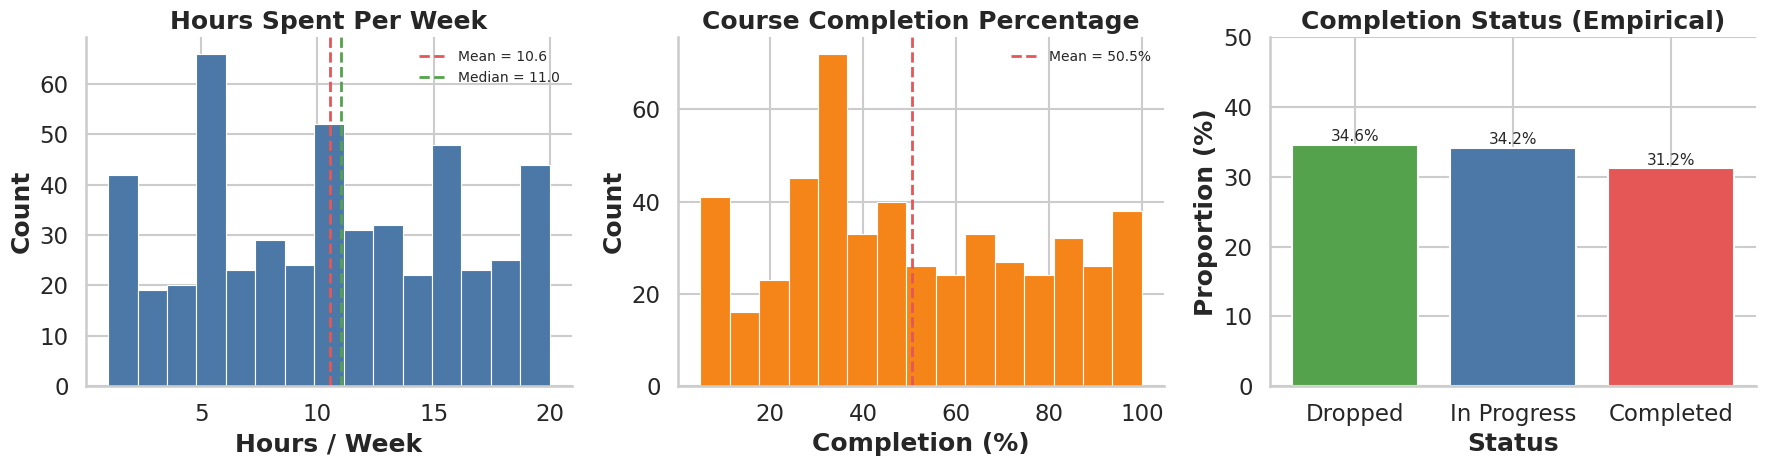


Descriptive Stats:
       Hours_Spent_Per_Week  Course_Duration_Weeks  Completion_Percentage  \
count                500.00                 500.00                 500.00   
mean                  10.56                  13.26                  50.48   
std                    5.52                   6.51                  26.97   
min                    1.00                   2.00                   5.00   
25%                    6.00                   8.00                  30.75   
50%                   11.00                  13.50                  46.00   
75%                   15.00                  19.00                  73.00   
max                   20.00                  24.00                 100.00   

       Satisfaction_Score  
count              500.00  
mean                 3.02  
std                  1.43  
min                  1.00  
25%                  2.00  
50%                  3.00  
75%                  4.00  
max                  5.00  


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1a. Distribution of Hours Spent Per Week
axes[0].hist(df['Hours_Spent_Per_Week'], bins=15, color='#4C78A8',
             edgecolor='white', linewidth=0.8)
axes[0].axvline(df['Hours_Spent_Per_Week'].mean(), color='#E45756',
                lw=2, linestyle='--', label=f"Mean = {df['Hours_Spent_Per_Week'].mean():.1f}")
axes[0].axvline(df['Hours_Spent_Per_Week'].median(), color='#54A24B',
                lw=2, linestyle='--', label=f"Median = {df['Hours_Spent_Per_Week'].median():.1f}")
axes[0].set_title('Hours Spent Per Week')
axes[0].set_xlabel('Hours / Week')
axes[0].set_ylabel('Count')
axes[0].legend(frameon=False, fontsize=10)

# 1b. Completion Percentage distribution
axes[1].hist(df['Completion_Percentage'], bins=15, color='#F58518',
             edgecolor='white', linewidth=0.8)
axes[1].axvline(df['Completion_Percentage'].mean(), color='#E45756',
                lw=2, linestyle='--', label=f"Mean = {df['Completion_Percentage'].mean():.1f}%")
axes[1].set_title('Course Completion Percentage')
axes[1].set_xlabel('Completion (%)')
axes[1].set_ylabel('Count')
axes[1].legend(frameon=False, fontsize=10)

# 1c. Completion Status breakdown (empirical proportions)
status_props = df['Completion_Status'].value_counts(normalize=True) * 100
bars = axes[2].bar(status_props.index, status_props.values,
                   color=['#54A24B', '#4C78A8', '#E45756'], edgecolor='white')
axes[2].set_title('Completion Status (Empirical)')
axes[2].set_xlabel('Status')
axes[2].set_ylabel('Proportion (%)')
axes[2].set_ylim(0, 50)
for bar, v in zip(bars, status_props.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print('\nDescriptive Stats:')
print(df[['Hours_Spent_Per_Week', 'Course_Duration_Weeks',
          'Completion_Percentage', 'Satisfaction_Score']].describe().round(2))

### Method 1 – Empirical Distributions:

The dataset has 500 learners. Hours spent per week is roughly uniformly distributed
between 1–20 hours (mean = 10.6, median = 11.0), meaning learners don't cluster
around any particular study habit, effort is spread evenly across the board.

Completion Percentage is right skewed with a spike around 30–40%, meaning a large chunk of learners disengage early and never get far into their course. The mean completion sits at just 50.5%, which is low, half the learner base isn't finishing what they start.

The completion status breakdown tells a stark story: Dropped (34.6%) is actually the largest category, edging out In Progress (34.2%) and Completed (31.2%). Nearly 1 in 3 learners quits entirely and fewer than a third fully complete their course.

**Platform design implication:** Completion is the core problem here. With 35% dropout and only 31% full completion, the platform needs to rethink how it keeps learners engaged past the first few sessions, shorter modules, milestone rewards or personalized reminders could all be worth testing.

### Method 2 – t-test (Tech vs Non-Tech Completion):





/tmp/ipykernel_3354/3911560961.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Course_Type', y='Completion_Percentage',


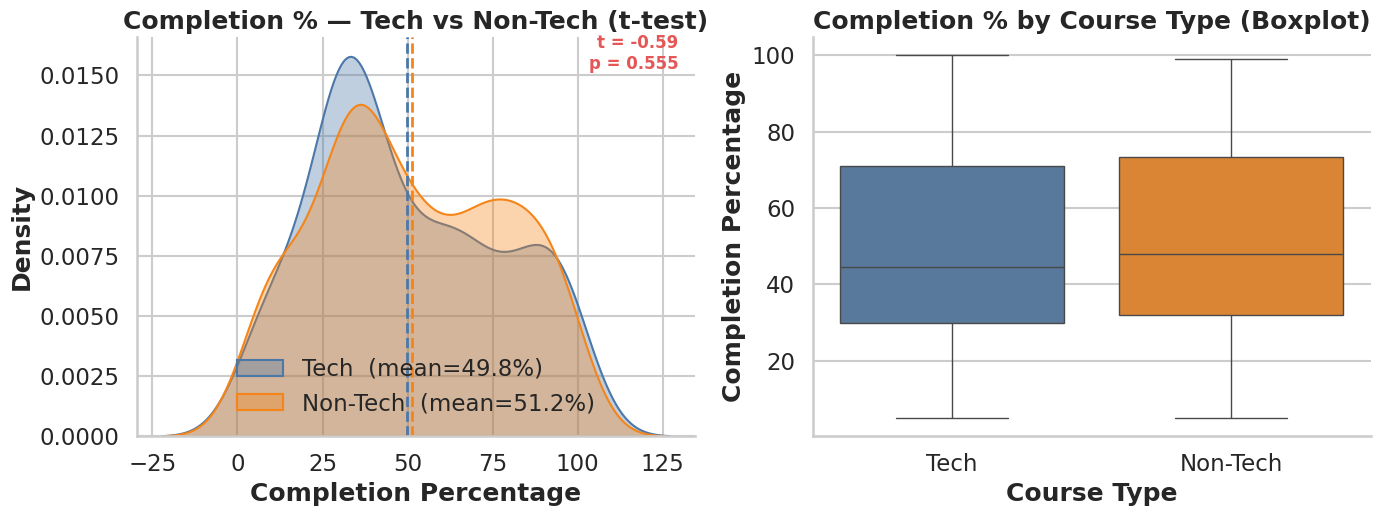

Tech mean:     49.75%   |  std: 27.10
Non-Tech mean: 51.18%   |  std: 26.88
t-statistic: -0.590
p-value:     0.5553
Result: NOT significant at α = 0.05


In [5]:
tech     = df[df['Course_Type'] == 'Tech']['Completion_Percentage']
non_tech = df[df['Course_Type'] == 'Non-Tech']['Completion_Percentage']

t_stat, p_val = ttest_ind(tech, non_tech, equal_var=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))


sns.kdeplot(tech,     fill=True, alpha=0.35, color='#4C78A8',
            label=f'Tech  (mean={tech.mean():.1f}%)', ax=axes[0])
sns.kdeplot(non_tech, fill=True, alpha=0.35, color='#F58518',
            label=f'Non-Tech  (mean={non_tech.mean():.1f}%)', ax=axes[0])
axes[0].axvline(tech.mean(),     color='#4C78A8', lw=2, linestyle='--')
axes[0].axvline(non_tech.mean(), color='#F58518', lw=2, linestyle='--')
axes[0].set_title("Completion % — Tech vs Non-Tech (t-test)")
axes[0].set_xlabel('Completion Percentage')
axes[0].set_ylabel('Density')
axes[0].legend(frameon=False)
axes[0].text(0.97, 0.92, f't = {t_stat:.2f}\np = {p_val:.3f}',
             transform=axes[0].transAxes, ha='right', fontsize=12,
             color='#E45756', weight='bold')


sns.boxplot(data=df, x='Course_Type', y='Completion_Percentage',
            palette=['#4C78A8', '#F58518'], ax=axes[1])
axes[1].set_title('Completion % by Course Type (Boxplot)')
axes[1].set_xlabel('Course Type')
axes[1].set_ylabel('Completion Percentage')

plt.tight_layout()
plt.show()

print(f'Tech mean:     {tech.mean():.2f}%   |  std: {tech.std():.2f}')
print(f'Non-Tech mean: {non_tech.mean():.2f}%   |  std: {non_tech.std():.2f}')
print(f't-statistic: {t_stat:.3f}')
print(f'p-value:     {p_val:.4f}')
print(f'Result: {"SIGNIFICANT" if p_val < 0.05 else "NOT significant"} at α = 0.05')

I ran a Welch's t-test to check whether Tech and Non-Tech learners complete
different proportions of their courses.

Results:
- Tech mean: 49.75%  |  Non-Tech mean: 51.18%
- t = -0.59,  p = 0.555
- Result: NOT significant at α = 0.05

The two distributions (KDE curves) overlap almost completely and the boxplots
are nearly identical in spread and median. The 1.4 percentage point difference
between groups is tiny and well within the range of random variation, we fail
to reject H₀.

Whether a course is technical or non-technical
has no meaningful effect on how much of it learners complete. Course type alone isn't
the lever. This actually shifts the question to why learners drop out, dropout
reason, platform choice or hours invested are likely better predictors than the
subject matter itself.


## Method 3 – ANOVA (Satisfaction by Experience Level):

/tmp/ipykernel_3354/4116062364.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Experience_Level', y='Satisfaction_Score',


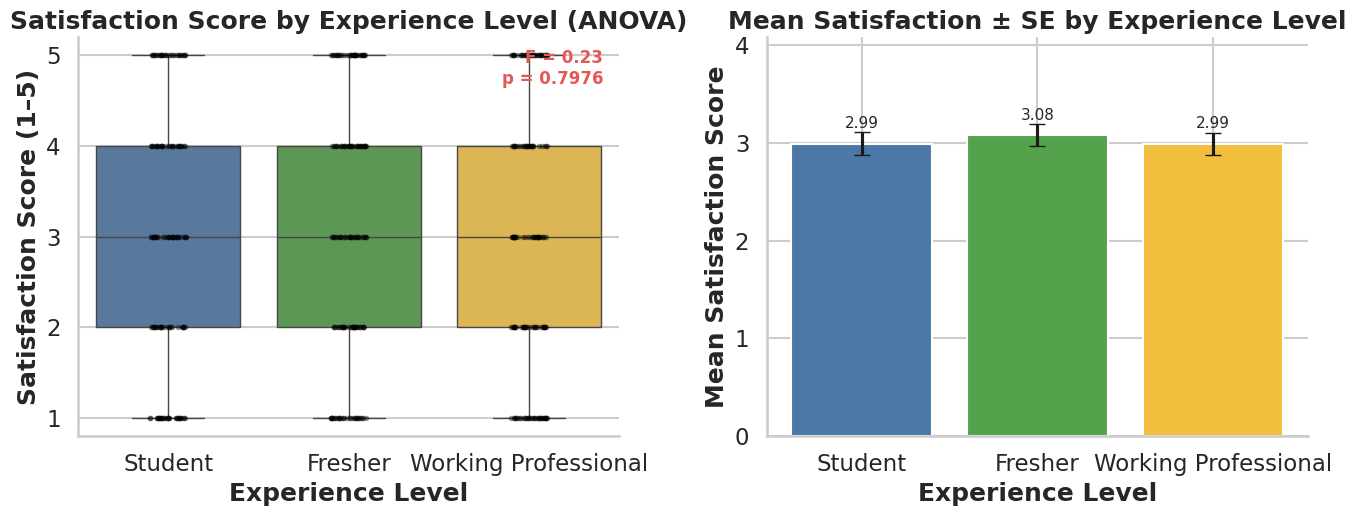

Student mean:              2.994
Fresher mean:              3.082
Working Professional mean: 2.988

F-statistic: 0.226
p-value:     0.7976
Result: NOT significant at α = 0.05


In [6]:
students = df[df['Experience_Level'] == 'Student']['Satisfaction_Score']
freshers = df[df['Experience_Level'] == 'Fresher']['Satisfaction_Score']
workers  = df[df['Experience_Level'] == 'Working Professional']['Satisfaction_Score']

F_stat, p_anova = f_oneway(students, freshers, workers)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))


sns.boxplot(data=df, x='Experience_Level', y='Satisfaction_Score',
            palette=['#4C78A8', '#54A24B', '#F2BE3E'], ax=axes[0],
            order=['Student', 'Fresher', 'Working Professional'])
sns.stripplot(data=df, x='Experience_Level', y='Satisfaction_Score',
              color='black', size=4, alpha=0.4, ax=axes[0],
              order=['Student', 'Fresher', 'Working Professional'])
axes[0].set_title('Satisfaction Score by Experience Level (ANOVA)')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Satisfaction Score (1–5)')
axes[0].text(0.97, 0.97, f'F = {F_stat:.2f}\np = {p_anova:.4f}',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=12, color='#E45756', weight='bold')


means = df.groupby('Experience_Level')['Satisfaction_Score'].mean().reindex(
        ['Student', 'Fresher', 'Working Professional'])
sems  = df.groupby('Experience_Level')['Satisfaction_Score'].sem().reindex(
        ['Student', 'Fresher', 'Working Professional'])
axes[1].bar(means.index, means.values, yerr=sems.values, capsize=6,
            color=['#4C78A8', '#54A24B', '#F2BE3E'], edgecolor='white')
axes[1].set_title('Mean Satisfaction ± SE by Experience Level')
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Mean Satisfaction Score')
axes[1].set_ylim(0, means.max() + 1)
for i, (v, se) in enumerate(zip(means.values, sems.values)):
    axes[1].text(i, v + se + 0.05, f'{v:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Student mean:              {students.mean():.3f}')
print(f'Fresher mean:              {freshers.mean():.3f}')
print(f'Working Professional mean: {workers.mean():.3f}')
print(f'\nF-statistic: {F_stat:.3f}')
print(f'p-value:     {p_anova:.4f}')
print(f'Result: {"SIGNIFICANT" if p_anova < 0.05 else "NOT significant"} at α = 0.05')

I used a one way ANOVA to test whether satisfaction scores differ across
Students, Freshers and Working Professionals.

Results:
- Student mean: 2.994  |  Fresher mean: 3.082  |  Working Professional mean: 2.988
- F = 0.226,  p = 0.7976
- Result: NOT significant at α = 0.05

All three boxplots span the full 1–5 range with nearly identical medians at 3.
The group means differ by less than 0.1 points, essentially the same score.
The F-statistic of 0.226 is very close to 0, meaning variance between groups is
far smaller than variance within groups.

Satisfaction on this platform is uniformly mediocre (~3/5) regardless of whether you are a student, a fresher, or a working professional. No one group is meaningfully happier or more frustrated than another. This suggests satisfaction is driven by something other than background, possibly
platform UX, course quality or individual expectations. A followup analysis
comparing satisfaction by Platform (Coursera vs Udemy vs edX etc.) would be a
more revealing cut of this data.

## Summary & Conclusion

Going into this analysis, I expected learner background and course type to be
meaningful predictors of how well people do on online learning platforms. The
data told a different story.

The empirical distribution (Method 1) was the most revealing starting point.
With 500 learners, I found that dropout (34.6%) is actually the most common
outcome. More learners quit than fully complete their course (31.2%). Average
completion sits at just 50.5%, and study hours are spread uniformly across
1–20 hrs/week with no clear engaged learner cluster. Before running any
formal tests this alone tells me the platform has a retention problem not
just a completion problem.

For the t-test (Method 2), I compared course completion between Tech and
Non-Tech learners. The means were nearly identical, 49.75% vs 51.18% and
the p-value of 0.555 gives no reason to reject the null. Course subject just
does not drive completion. If I were advising the platform team, I would stop
segmenting users by course type for retention strategy because it's not where
the signal is.

The ANOVA (Method 3) tested whether satisfaction differed across Students,
Freshers and Working Professionals. Again, no significant difference
(F = 0.226, p = 0.798). All three groups hovered around 3/5, uniformly
average. What surprised me here is how consistent that mediocrity is across
very different user types. A student and a working professional have completely
different life contexts yet they rate their experience the same.

Taken together, these three results point me toward a followup question I
didn't originally plan for: if neither learner background nor course type
explains outcomes, what does? My next step would be to look at dropout reason,
platform (Coursera vs Udemy vs YouTube etc.) and whether hours spent per week
actually predicts completion percentage. Those feel like the real levers hiding
in this dataset.